# Three Algorithm Classification on Iris Dataset

This notebook loads the local `Iris.csv` dataset, preprocesses the data, and trains three classification algorithms: Logistic Regression, Decision Tree, and Random Forest. Evaluation includes accuracy, classification reports, and confusion matrices.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier



# Load dataset from local CSV
df = pd.read_csv('Iris.csv')
df = df.drop(columns=['Id'], errors='ignore')
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [12]:
# Prepare features and labels
X = df.drop(columns=['Species'])
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Species'])
target_names = label_encoder.classes_

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Training shape:', X_train.shape)
print('Testing shape:', X_test.shape)

Training shape: (120, 4)
Testing shape: (30, 4)


In [4]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=200, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
print('### Logistic Regression')
print('Accuracy:', round(accuracy_score(y_test, y_pred_lr) * 100, 2), '%')
print('Classification Report:')
print(classification_report(y_test, y_pred_lr, target_names=target_names))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_lr))

### Logistic Regression
Accuracy: 96.67%
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [5]:
# Decision Tree
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)
y_pred_dt = decision_tree.predict(X_test)
print('### Decision Tree')
print('Accuracy:', round(accuracy_score(y_test, y_pred_dt) * 100, 2), '%')
print('Classification Report:')
print(classification_report(y_test, y_pred_dt, target_names=target_names))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_dt))

### Decision Tree
Accuracy: 93.33%
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


In [6]:
# Random Forest
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)
y_pred_rf = random_forest.predict(X_test)
print('### Random Forest')
print('Accuracy:', round(accuracy_score(y_test, y_pred_rf) * 100, 2), '%')
print('Classification Report:')
print(classification_report(y_test, y_pred_rf, target_names=target_names))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_rf))

### Random Forest
Accuracy: 90.00%
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


# Visualizations
The charts below compare model accuracy and show confusion matrix heatmaps for each algorithm.

C:\Users\rs889\AppData\Local\Temp\ipykernel_18512\13171126.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(accuracies.keys()), y=[v * 100 for v in accuracies.values()], palette='pastel')


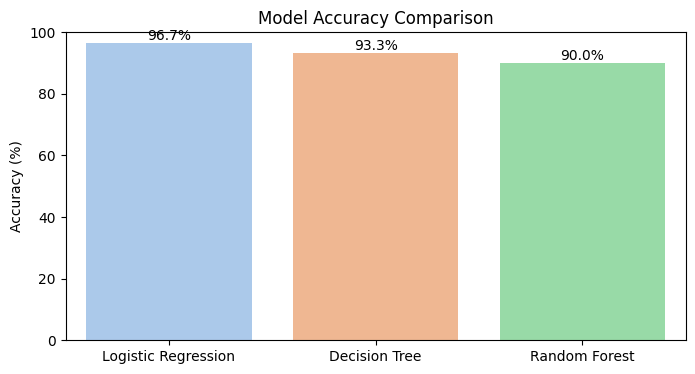

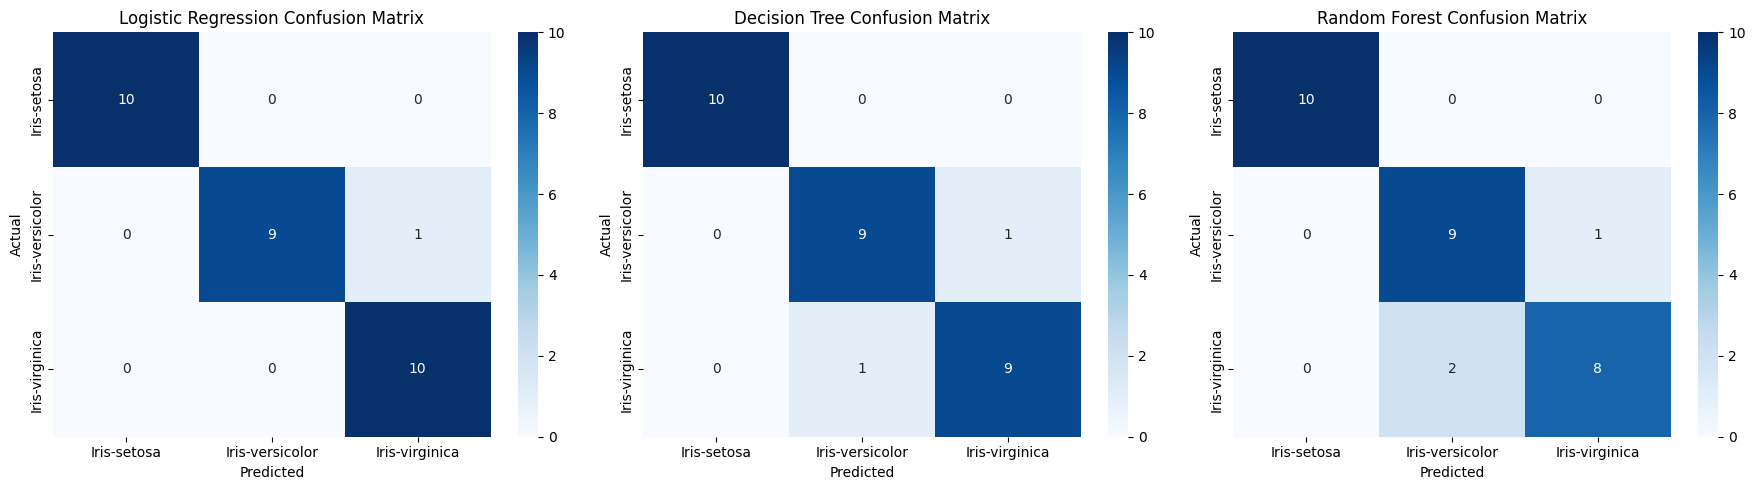

In [ ]:
# Accuracy comparison and confusion matrix plots
accuracies = {
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'Decision Tree': accuracy_score(y_test, y_pred_dt),
    'Random Forest': accuracy_score(y_test, y_pred_rf),
}

plt.figure(figsize=(8, 4))
names = list(accuracies.keys())
scores = [v * 100 for v in accuracies.values()]
plt.bar(names, scores, color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
for i, score in enumerate(scores):
    plt.text(i, score + 1, f'{score:.1f}%', ha='center')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name, y_pred in zip(axes, accuracies.keys(), [y_pred_lr, y_pred_dt, y_pred_rf]):
    cm = confusion_matrix(y_test, y_pred)
    ax.imshow(cm, cmap='Blues')
    ax.set_title(name + ' Confusion Matrix')
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(target_names)
    ax.set_yticklabels(target_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.tight_layout()
plt.show()